# Variables and Objects


In [62]:
import sys
from pathlib import Path

current = Path.cwd()
for parent in [current, *current.parents]:
    if (parent / '_config.yml').exists():
        project_root = parent  # ← Add project root, not chapters
        break
else:
    project_root = Path.cwd().parent.parent

sys.path.insert(0, str(project_root))

from shared import thinkpython, diagram, jupyturtle, download

# Register as top-level modules so direct imports work in subsequent cells
sys.modules['thinkpython'] = thinkpython
sys.modules['diagram'] = diagram
sys.modules['jupyturtle'] = jupyturtle
sys.modules['download'] = download


```{contents}
:local:
:depth: 2
```

```{index} variable
```
## Variables

Programs need a way to remember values. In Python, a **variable** is a name that refers to an object. The object stores the value; the name lets your program use that value again.

In Python, to create a variable, use an **assignment statement**. An assignment statement has three parts: 

1. the **name** of the variable on the left,
2. the equals operator, **`=`**, and
3. an **expression** on the right.

Also, note that:

- A **variable** is a name that refers to a value.
- When you run an assignment **_statement_**, there is **no output**. Python creates the variable and gives it a value, but the assignment statement has no visible effect.
- A literal value is also an expression.
- After creating a variable, you can use it as an expression. 

Use the **assignment** operator (`=`) to bind a **name** to a **value**. Read the statement below as "**assign the value on the right to the name on the left.**" Python evaluates the right side first, then stores the reference in the name.

In [94]:
score = 87
bonus = 5
score = score + bonus
print(score)

92


A name can be rebound to a different object. **Reassignment** does not edit the old object; it makes the name refer to another object.

In [74]:
label = "draft"
print(label)

label = "final"
print(label)

print("label was", label, "and is now", label)
print(f"label was {label} and is now {label}")  # f-string

draft
final
label was final and is now final
label was final and is now final


### Expressions and Variables

In this example below, the expression is an integer (a literal is an expression in Python). 

In [63]:
n = 17

You can also do a **multiple assignment** to create multiple variables with one assignment:

In [64]:
m, n = 7, 17     ### m = 7 and n = 17

In the following examples, the expressions are:
- a floating-point number
- an expression (`pi * 2`)

In [65]:
pi = 3.141592653589793
pi2 = pi * 2

And in the following example, the expression is a string.

In [66]:
message = 'And now for something completely different'

A variable can be an expression, so we can display the value of `message` by asking Python to evaluate it:

In [67]:
message

'And now for something completely different'

You can also use a **variable** as part of an expression with arithmetic operators.

In [68]:
print(n + 25)
print(2 * pi)
print(message + " we will learn Python")

42
6.283185307179586
And now for something completely different we will learn Python


### Variables as Arguments

And you can use a variable as the argument when you call a function.

In [69]:
print(round(pi))       ### "round()" is a built-in function
print(len(message))    ### the number of characters in the string 

3
42


In [70]:
course = "Python"
week = 2
print(course)
print(week)

Python
2


```{index} state diagram
```
### State diagrams

A common way to represent variables on paper is to write the name with an arrow pointing to its value. 

In [71]:
### code for displaying state diagrams
### dont' worry about the code here

import math

from diagram import make_binding, Frame

binding = make_binding("message", 'And now for something completely different')
binding2 = make_binding("n", 17)
binding3 = make_binding("pi", 3.141592653589793)

frame = Frame([binding2, binding3, binding])

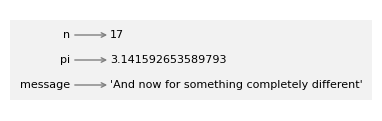

In [72]:
### code for displaying state diagrams
### dont' worry about the code here

from diagram import diagram, adjust

width, height, x, y = [3.62, 1.01, 0.6, 0.76]
ax = diagram(width, height)
bbox = frame.draw(ax, x, y, dy=-0.25)
adjust(x, y, bbox);

This kind of figure is called a **state diagram** because it shows what state each of the variables is in (think of it as the variable's state of mind).
We'll use state diagrams throughout the book to represent a model of how Python stores variables and their values.

```{index} variable: naming
```
### Naming Convention

General Python variable naming follows the convention from the official [PEP 8 style guidelines](https://peps.python.org/pep-0008/#naming-conventions), although conventions such as Google Python:

1. Length: Names can be as long as you like.
2. Containing: Names can contain alphanumeric characters (letters and numbers) and underscores. Special characters (e.g., @, #, $) are not allowed.
3. Begin with: Can begin with an **underscore** or a **letter**, but can't begin with a number.
4. Letter Case:
   1. Names are case-sensitive. `age`, `Age`, and `AGE` are three distinct variables.
   2. It is conventional to use only **lowercase** letters for variable names, although it is legal to use uppercase letters.
   3. Use **`snake_case`** for variable names: All lowercase with **underscores** between words. Example: total_price, student_name, is_active. (camelCase is for C#/Java/JavaScript variable names.)
   4. For class names, use **PascalCase**, or `upper camel case`, convention; e.g., `class StudentRecord`. 
7. Avoid **keywords** and **built-in function** names for naming variables.
8. Constants: For constants, use ALL_CAPS with underscores; e.g., MAX_SIZE = 100, PI = 3.14159.

The only punctuation that can appear in a variable name is the underscore character, `_`. It is often used in names with multiple words, such as `your_name` or  `airspeed_of_unladen_swallow`.

If you give a variable an illegal name, you get a syntax error.
The name `million!` is illegal because it contains punctuation.

To show all the Python keywords (which you don't want to use as variable names):

In [93]:
from keyword import kwlist

print("Number of Python keywords:", len(kwlist))
print("First five Python keywords:", kwlist)

Number of Python keywords: 35
First five Python keywords: ['False', 'None', 'True', 'and', 'as', 'assert', 'async', 'await', 'break', 'class', 'continue', 'def', 'del', 'elif', 'else', 'except', 'finally', 'for', 'from', 'global', 'if', 'import', 'in', 'is', 'lambda', 'nonlocal', 'not', 'or', 'pass', 'raise', 'return', 'try', 'while', 'with', 'yield']


Good naming makes code easier to scan and therefore is great for **documentation**. In Python, variable names usually use **`snake_case`**: lowercase words separated by underscores.

| Pattern | Use |
|---|---|
| `student_count` | regular variable |
| `MAX_RETRIES` | constant by convention |
| `_temporary` | internal helper name by convention |

Avoid names that shadow common built-ins, such as `list`, `sum`, `str`, or `type`.

In [75]:
student_count = 28
average_score = 84.6
is_passing = average_score >= 70
print(student_count, average_score, is_passing)

28 84.6 True


In [76]:
### Checkpoint: create useful names
# Create variables named course_name, enrolled_students, and average_grade.
# Print a sentence like: Python has 28 students with an average grade of 84.6.
### Your code starts here.



### Your code ends here.

In [77]:
### Solution
course_name = "Python"
enrolled_students = 28
average_grade = 84.6

print(f"{course_name} has {enrolled_students} students with an average grade of {average_grade}.")



Python has 28 students with an average grade of 84.6.


## Built-in Data Types

### Values and Types

You have seen several different kinds of **values**. For example:

* `2` is an integer,
* `42.0` is a floating-point number, and 
* `'Hello'` is a string.

## Objects and Mutation

In Python, **everything is an object**, and every object has: 
- **identity** (unique ID) (`id()`)
- **value**
- **type** (`type()`)

An object has a value, a type, and an identity. Use `type()` to inspect the kind of data the object refers to, and use `id()` to find the identification the object has.

### Types

In [78]:
items = 12
price = 4.99
name = "notebook"
in_stock = True

print(type(items))
print(type(price))
print(type(name))
print(type(in_stock))

<class 'int'>
<class 'float'>
<class 'str'>
<class 'bool'>


### Object ID
In Python, every object has a unique identity, which can be obtained using the built-in `id()` function. An identity is a unique integer that remains constant for an object throughout its lifetime. This is useful for understanding how Python manages objects in memory and for distinguishing between objects that have the same value. Notice that these objects have different IDs.

You can use the `id()` function when you need to reason about identity. In the examples below, we see different variables have different IDs.

In [79]:
### different variables (objects) have different IDs

num1 = 42
num2 = 3.14
greeting = "hello"
fruits = ["apple", "banana", "cherry"]

print(id(num1))
print(id(num2))
print(id(greeting))
print(id(fruits))

4342408480
4460063280
4455859088
4494865408


## Aliasing and Mutation

Some objects can be changed after they are created. Lists and dictionaries are **mutable**. Integers, floats, strings, tuples, booleans, and `None` are **immutable**.

When two names refer to the same **mutable object**, changing the object through one name affects what you see through the other name. This is called **aliasing**, meaning different variables with the same value will have not only the same values but also the same IDs.

Here, you use the `==` operator to check value equality and the `is` keyword to check object identity. 

For **immutable** types, Python may bind the same value to different variables with the same type to save memory. Therefore, different variables with the same value **may** have the same ID. 

In [80]:
num1=100
num2=100
name1 = "Alice"
name2 = "Alice"

print(num1 == num2)      ### Ture; same value. '==' test same value
print(num1 is num2)      ### True; same ID. 'is' test same ID
print(name1 == name2)
print(name1 is name2)

print(id(num1), id(num2))
print(id(name2), id(name2))

True
True
True
True
4342410336 4342410336
4494820720 4494820720


Note that small integers and simple string literals are often *interned* — reused as the same object — as a memory optimization. This is a CPython implementation detail, not something your code should ever rely on. If you test different variables with the same larger number with `is`, they may not be the same.

In [81]:
x = 100
y = 100
print(x == y)     ### True
print(x is y)     ### True

True
True


In [82]:
x = 1000000000000
y = 1000000000000
print(x == y)     ### True
print(x is y)     ### False

True
False


Basically, creating a new variable by assigning a value should create a new object.

### Aliasing
Aliasing happens when two or more variable names refer to the **same object** in memory, rather than each having its own independent copy. Because they point to the same object, changing the object through one name is visible through the other name too. 

In [83]:
a = [10, 20, 30]
b = a     ### b is now an ALIAS for a — same object, not a copy

print(a == b)             ### True; same value
print(a is b)             ### False; different ID == different objects

print(id(a))
print(id(b))

True
True
4494338176
4494338176


If you assign the same values to two different variables through separate assignments, they have separate copies of the same value. Therefore, variable assignments create new objects.

In [84]:
a = [10, 20, 30]
b = [10, 20, 30]

print(a == b)             ### True; same value
print(a is b)             ### False; different ID == different objects

print(id(a))
print(id(b))

True
False
4494856576
4467487104


### Mutability
For **mutable** objects such as `list`, aliasing can have a surprising side effect. In the example below, you see that after creating `b` as the **alias** of `a`, when the value of `b` changes, the value of `a` will change along. 

In [85]:
a = [10, 20, 30]
b = a                     ### b is an "alias" of a

print(a)                  ### [10, 20, 30]
print(b)                  ### [10, 20, 30]

print()

print("a == b: ", a == b)     ### '==' for equality (same value) test
print("a is b: ", a is b)     ### '==' for equality (same value) test
print("id(a) == id(b) ", id(a) == id(b))
print(a, id(a))         ### a is changed as well because a and b are the same object
print(b, id(b))

print()

print("b.append(40)")
b.append(40)     ### change b

print()

print(a, id(a))         ### a is changed as well because a and b are the same object
print(b, id(b))


[10, 20, 30]
[10, 20, 30]

a == b:  True
a is b:  True
id(a) == id(b)  True
[10, 20, 30] 4494867776
[10, 20, 30] 4494867776

b.append(40)

[10, 20, 30, 40] 4494867776
[10, 20, 30, 40] 4494867776


Another example of aliasing.

In [86]:
nums = [1, 2, 3]
print(f"nums is {nums} and has id {id(nums)}")

alias = nums    ### Create an alias for nums
print(f"alias is {alias} and has id {id(alias)}")

print("\nmodifying the list using the alias...")
alias.append(4) ### Modify the list using the alias
print(f"\nalias is now {alias} and has id {id(alias)}")

print(f"nums is now {nums} too, and has id {id(nums)}")

nums is [1, 2, 3] and has id 4494862464
alias is [1, 2, 3] and has id 4494862464

modifying the list using the alias...

alias is now [1, 2, 3, 4] and has id 4494862464
nums is now [1, 2, 3, 4] too, and has id 4494862464


This side effect does not happen with string aliasing, which is **immutable**. 

In [87]:
name1 = "Alice"
name2 = name1   ### Create an alias for name1
print(f"name1: {name1}")
print(f"name2: {name2}")
print(f"name1 == name2: {name1 == name2}")
print(f"name1 is name2: {name1 is name2}")

print(f"ID of name1: {id(name1)}")
print(f"ID of name2: {id(name2)}")

print("\nChanging name2 to 'Bob'...\n")
name2 = "Bob"   ### now name2 points to a new string object

print(f"name1: {name1}")
print(f"name2: {name2}")
print(f"name1 == name2: {name1 == name2}")
print(f"name1 is name2: {name1 is name2}")

print(f"ID of name1: {id(name1)}")
print(f"ID of name2: {id(name2)}")

print()

print("name2 has a new ID after assignment")

name1: Alice
name2: Alice
name1 == name2: True
name1 is name2: True
ID of name1: 4494820720
ID of name2: 4494820720

Changing name2 to 'Bob'...

name1: Alice
name2: Bob
name1 == name2: False
name1 is name2: False
ID of name1: 4494820720
ID of name2: 4497303968

name2 has a new ID after assignment


To avoid the side effect of **mutable** aliasing, use **reassignment** with the alias. Reassignment moves one name to a new object; it does not change the original object.

In [88]:
nums = [1, 2, 3]
alias = nums

alias = [1, 2, 3, 4]    #### Create a new list and assign it to alias
print(nums)
print(alias)

[1, 2, 3]
[1, 2, 3, 4]


In [89]:
### Checkpoint: mutation or reassignment?
# For each line below, add a comment saying whether it mutates an object or reassigns a name.
colors = ["red", "green"]
colors.append("blue")
colors = colors + ["purple"]
colors[0] = "orange"
print(colors)

['orange', 'green', 'blue', 'purple']


In [90]:
### Solution
colors = ["red", "green"]
colors.append("blue")          # mutates the existing list
colors = colors + ["purple"]   # reassigns colors to a new list
colors[0] = "orange"           # mutates the list
print(colors)



['orange', 'green', 'blue', 'purple']


## Summary

- Assignment binds a name to an object.
- Objects have values, types, and identities.
- `==` checks equal value; `is` checks same object.
- Mutation changes an object; reassignment changes which object a name refers to.
- F-strings are the standard way to combine text and values for output.